In [18]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.3 MB/s eta 0:00:00


In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data Mining Lab/financial_portfolio_data.csv')
df

,Date,Asset,Price
0,2023-07-10,Bond B,385.64
1,2023-03-03,Stock B,297.20
2,2023-09-13,Bond B,75.98
3,2023-01-07,Bond B,356.34
4,2023-06-04,Stock A,260.05
...,...,...,...
495,2023-03-30,Stock B,278.00
496,2023-06-27,Bond A,224.26
497,2023-07-16,Commodity A,457.96
498,2023-11-03,Bond B,57.23


In [38]:
# Convert to datetime
df["Date"] = pd.to_datetime(df["Date"])

assets = df['Asset'].unique()
assets

array(['Bond B', 'Stock B', 'Stock A', 'Commodity A', 'Bond A'],
      dtype=object)

In [41]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# To find (p,d,q)
def find_p_d_q(df):
  model_auto = auto_arima(
      df["Price"],
      seasonal=False,
      trace=True
  )
  return model_auto.order


def stock_prediction(asset):
  df_stock = df[df['Asset'] == asset].copy()

  # Sort
  df_stock = df_stock.sort_values(by='Date')

  # Handle duplicate dates by averaging prices for the same day
  df_stock = df_stock.groupby('Date')['Price'].mean().reset_index()

  # set date as index
  df_stock.set_index("Date", inplace=True)

  # Now apply frequency and interpolate the missing vales
  df_stock = df_stock.asfreq("D")
  df_stock["Price"] = df_stock["Price"].interpolate()

  # find (p,d,q) for ARIMA model
  order = find_p_d_q(df_stock)

  # build ARIMA model and fit it
  model = ARIMA(df_stock["Price"], order=order)
  model_fit = model.fit()

  forecast = model_fit.forecast(steps=30)

  # Add future dates
  future_dates = pd.date_range(
      start=df_stock.index[-1],
      periods=30,
      freq='D'
  )
  forecast.index = future_dates

  return df_stock["Price"], forecast

In [43]:
asset_predictions = {}
for asset in assets:
  print(f"Asset: {asset}")
  actual, forecast = stock_prediction(asset)
  asset_predictions[asset] = {
        "actual": actual,
        "forecast": forecast
    }
  print('-'*20)

Asset: Bond B
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=3982.095, Time=0.91 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=5154.707, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3977.563, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4746.733, Time=0.27 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=3978.469, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=3978.457, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=3980.457, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=3946.384, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=4346.557, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=3940.493, Time=0.23 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=3939.192, Time=0.11 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=3941.119, Time=0.17 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=3941.176, Time=0.26 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=3939.717, Time=0.60 sec
 ARIMA(4,0,1)(0,0,0

In [48]:
forecast_df = pd.DataFrame({
    asset: asset_predictions[asset]["forecast"]
    for asset in asset_predictions
})

print("**** Forecast Table ****")
print(forecast_df)

**** Forecast Table ****
                Bond B     Stock B  Stock A  Commodity A      Bond A
2023-12-22         NaN  418.130619      NaN          NaN         NaN
2023-12-23         NaN  404.189410      NaN          NaN         NaN
2023-12-24         NaN  378.722500      NaN          NaN         NaN
2023-12-25         NaN  358.221480  111.575          NaN         NaN
2023-12-26         NaN  341.718033  111.575          NaN         NaN
2023-12-27         NaN  328.432657  111.575          NaN         NaN
2023-12-28         NaN  317.737847  111.575          NaN         NaN
2023-12-29         NaN  309.128459  111.575          NaN         NaN
2023-12-30  351.286000  302.197850  111.575          NaN  174.201620
2023-12-31  351.916087  296.618666  111.575   283.766837  182.963969
2024-01-01  343.093733  292.127389  111.575   276.720927  204.897279
2024-01-02  333.387329  288.511883  111.575   287.149049  225.375011
2024-01-03  324.818877  285.601379  111.575   286.805463  240.935269
2024-01-0

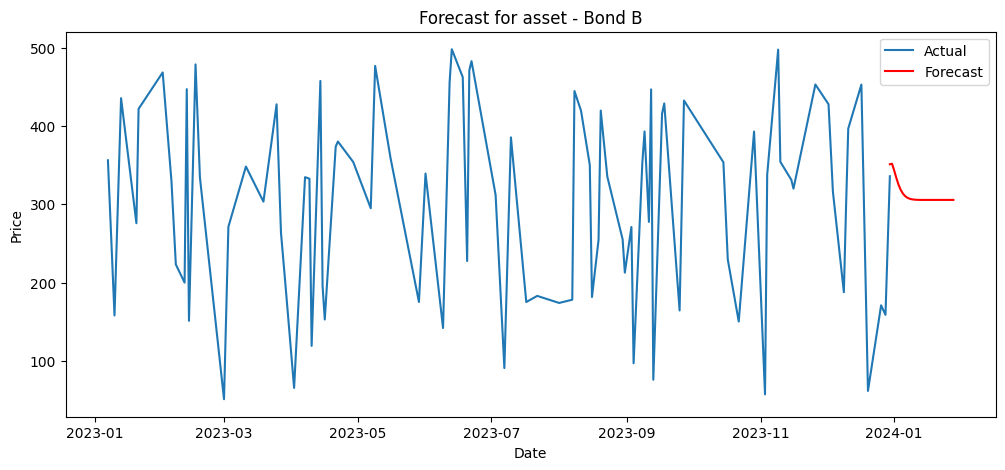

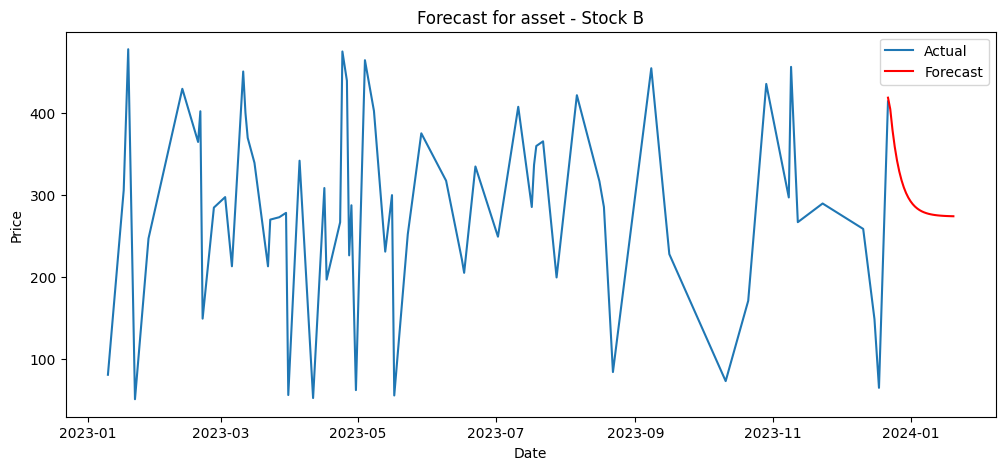

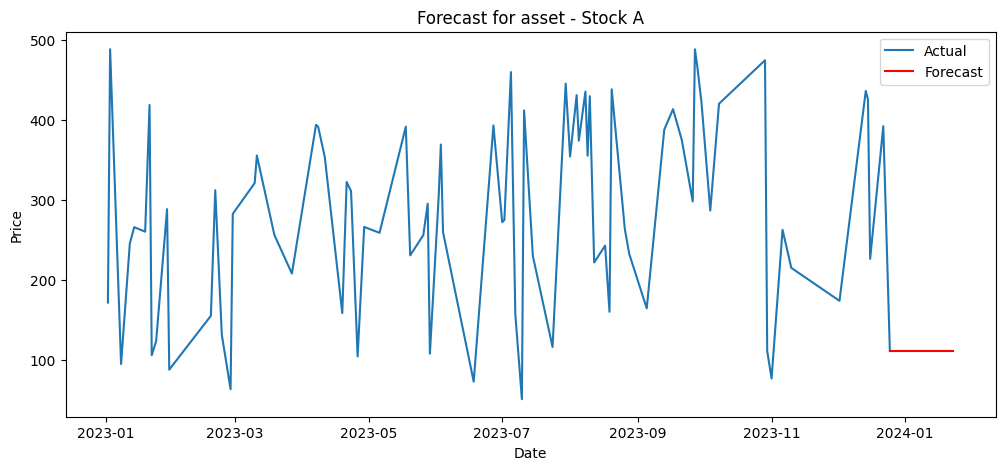

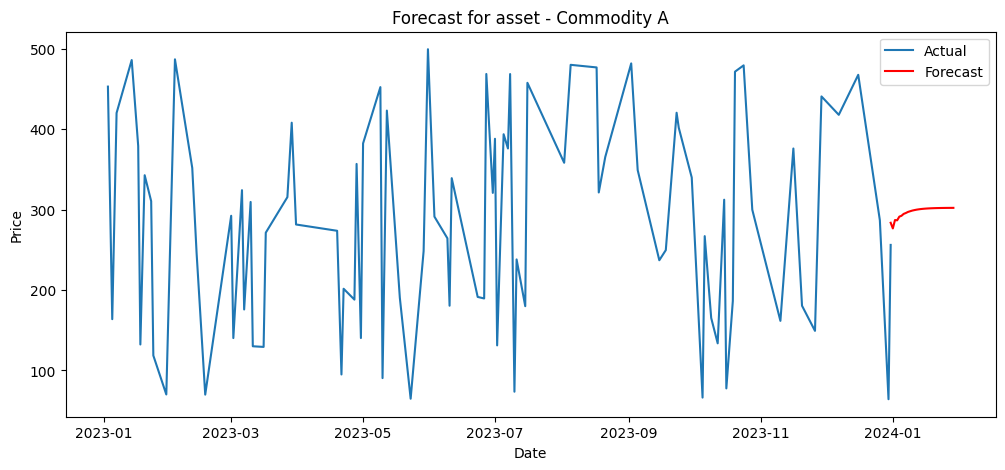

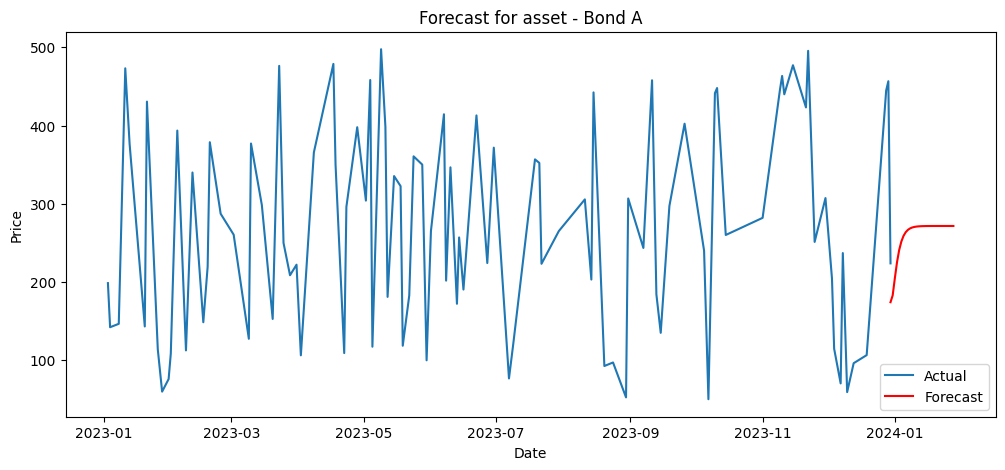

In [45]:
import matplotlib.pyplot as plt

def plot_prediction(actual, forecast, asset):
  plt.figure(figsize=(12,5))
  plt.title(f'Forecast for asset - {asset}')
  plt.plot(actual, label="Actual")
  plt.plot(forecast, label="Forecast", color="red")
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.legend()
  plt.show()

for asset in assets:
  actual = asset_predictions[asset]["actual"]
  forecast = asset_predictions[asset]["forecast"]
  plot_prediction(actual, forecast, asset)